# Performing pseudobulking on the `InSituExperiment` object

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, InSituExperiment, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd.load_all(skip="transcripts")
xd

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

### Create `InSituExperiment` from regions

In [5]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [6]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     9ba6109f  ++-++  0001879  Replicate 1        TMA         A-1
1     b78f9e57  ++-++  0001879  Replicate 1        TMA         A-2
2     fe108fa9  ++-++  0001879  Replicate 1        TMA         A-3
3     5a4e7f82  ++-++  0001879  Replicate 1        TMA         B-1
4     3139e041  ++-++  0001879  Replicate 1        TMA         B-2
5     ce9472df  ++-++  0001879  Replicate 1        TMA         B-3

In [7]:
from insitupy.tools import generate_pseudobulk

In [10]:
exp.data[0]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None

    ➤ images
       CD20:	(4706, 4706)
       HE:	(4706, 4706, 3)
       HER2:	(4706, 4706)
       nuclei:	(4706, 4706)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 4847 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leide

In [12]:
psbulk = generate_pseudobulk(
    exp,
    celltype_col='cell_type_dc_sub_final',
    cells_layer=None,
    counts_layer='counts',
    mode='sum'
    )

In [14]:
psbulk.to_df()

,MS4A1,AIF1,BASP1,PDK4,DPT,STC1,AVPR1A,C1QA,TCEAL7,KLRF1,...,BACE2,C6orf132,ENAH,C2orf42,ACTG2,CAVIN2,SERHL2,SMAP2,FOXC2,S100A14
9ba6109f_B cells,88.0,48.0,96.0,60.0,22.0,4.0,6.0,37.0,1.0,9.0,...,21.0,2.0,49.0,10.0,66.0,0.0,22.0,73.0,1.0,22.0
9ba6109f_Breast cancer subtype 1,1.0,53.0,428.0,114.0,16.0,134.0,8.0,13.0,5.0,9.0,...,119.0,178.0,1405.0,77.0,1057.0,5.0,1361.0,159.0,5.0,1017.0
9ba6109f_Breast cancer subtype 2,1.0,2.0,24.0,9.0,1.0,12.0,0.0,2.0,1.0,1.0,...,24.0,18.0,57.0,1.0,81.0,0.0,73.0,9.0,1.0,141.0
9ba6109f_Breast cancer subtype 3,0.0,22.0,91.0,29.0,17.0,8.0,1.0,12.0,0.0,3.0,...,18.0,17.0,157.0,6.0,117.0,1.0,83.0,12.0,1.0,83.0
9ba6109f_Breast cancer subtype 4,7.0,130.0,1310.0,392.0,18.0,355.0,16.0,44.0,24.0,44.0,...,1270.0,814.0,4902.0,195.0,4050.0,23.0,5313.0,544.0,24.0,9050.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ce9472df_Endothelial cells,4.0,79.0,85.0,510.0,81.0,20.0,28.0,72.0,16.0,12.0,...,149.0,6.0,182.0,17.0,292.0,311.0,63.0,63.0,12.0,77.0
ce9472df_Macrophages,8.0,850.0,592.0,1088.0,176.0,10.0,12.0,421.0,20.0,24.0,...,67.0,36.0,117.0,22.0,672.0,25.0,164.0,453.0,12.0,293.0
ce9472df_Smooth muscle cells,1.0,45.0,38.0,196.0,20.0,3.0,70.0,25.0,9.0,2.0,...,45.0,3.0,92.0,4.0,144.0,19.0,20.0,35.0,17.0,48.0
ce9472df_Stromal cells,35.0,440.0,720.0,1258.0,777.0,3.0,39.0,295.0,72.0,25.0,...,264.0,65.0,464.0,46.0,976.0,62.0,255.0,200.0,16.0,644.0


In [ ]:
psbulk = generate_pseudobulk(
    exp,
    sample_col='batch',
    groups_col='cell_type_dc_sub_final',
    counts_layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=1000,
    skip_checks=False,
    min_prop=None,
    min_smpls=None,
    remove_empty=True
    )

TypeError: generate_pseudobulk() got an unexpected keyword argument 'sample_col'

In [42]:
psbulk

AnnData object with n_obs × n_vars = 60 × 297
    obs: 'batch', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [43]:
psbulk.obs

,batch,cell_type_dc_sub_final,psbulk_cells,psbulk_counts
9f4a2a5c-Adipocytes,9f4a2a5c,Adipocytes,11.0,2728.0
1accc48d-B cells,1accc48d,B cells,184.0,30929.0
254b31d5-B cells,254b31d5,B cells,29.0,6606.0
55d07bd6-B cells,55d07bd6,B cells,67.0,13314.0
9f4a2a5c-B cells,9f4a2a5c,B cells,110.0,18702.0
c3478b1a-B cells,c3478b1a,B cells,178.0,33777.0
cd61d9fc-B cells,cd61d9fc,B cells,86.0,12128.0
254b31d5-Breast cancer subtype 1,254b31d5,Breast cancer subtype 1,967.0,213588.0
55d07bd6-Breast cancer subtype 1,55d07bd6,Breast cancer subtype 1,83.0,23719.0
9f4a2a5c-Breast cancer subtype 1,9f4a2a5c,Breast cancer subtype 1,1742.0,486409.0


In [44]:
psbulk.layers["psbulk_props"]

array([[0.36363636, 0.90909091, 0.72727273, ..., 0.36363636, 1.        ,
        0.45454545],
       [0.16847826, 0.44021739, 0.4673913 , ..., 0.29891304, 0.54347826,
        0.20108696],
       [0.27586207, 0.75862069, 0.72413793, ..., 0.4137931 , 0.72413793,
        0.55172414],
       ...,
       [0.21165644, 0.66257669, 0.66871166, ..., 0.31288344, 0.52760736,
        0.23006135],
       [0.03246753, 0.56926407, 0.65367965, ..., 0.35497835, 0.62554113,
        0.21861472],
       [0.14634146, 0.57839721, 0.56445993, ..., 0.34843206, 0.43554007,
        0.20209059]], shape=(60, 297))

## Analyze pseudobulk data

The resulting pseudobulk `AnnData` object can be used for subsequent analyses using e.g. packages like `decoupler`. A tutorial on how to analyze pseudobulk data with `decoupler` can be found [here](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html).

In [45]:
import decoupler as dc

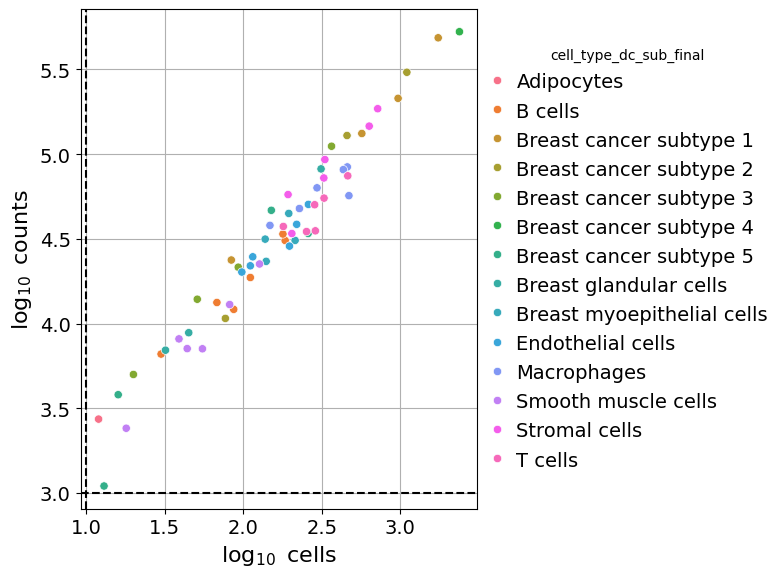

In [48]:
dc.pl.filter_samples(
    adata=psbulk,
    groupby=["cell_type_dc_sub_final"],
    min_cells=10,
    min_counts=1000,
    figsize=(8,6),
)

To continue with the analysis one requires more conditions than available in this breast cancer dataset.